# 第 7 章 · 决策树与聚类代码实验

本页连接两个经典学习任务：用葡萄酒化学指标做分类，用鸢尾花形态指标做聚类。读者重点看模型如何从数据中形成规则、簇和可解释的指标。

[章节网页](../ch7.html)

## 运行内容

- 训练 Wine 决策树
- 查看特征重要性
- 比较 Iris 不同 k 与肘部曲线

## 0. 葡萄酒数据

先看样本、特征和类别。决策树要学习的是：哪些化学指标最能把不同葡萄酒类别分开。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import subprocess
import sys
import warnings
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes, load_iris, load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    confusion_matrix,
    mean_squared_error,
    precision_recall_fscore_support,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 加载 Wine 经典分类数据集：13 个化学特征预测 3 类葡萄酒。
wine = load_wine(as_frame=True)
tree_df = wine.frame.copy()
feature_names = wine.feature_names
class_names = list(wine.target_names)
tree_df["类别名称"] = tree_df["target"].map(dict(enumerate(class_names)))

X_tree = tree_df[feature_names]
y_tree = tree_df["target"]

summary_df = pd.DataFrame(
    {
        "样本数": [len(tree_df)],
        "特征数": [len(feature_names)],
        "类别数": [len(class_names)],
    }
)
display(summary_df)
display(tree_df.head(8))
display(tree_df["类别名称"].value_counts().rename_axis("类别").reset_index(name="样本数"))

,样本数,特征数,类别数
0,178,13,3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,类别名称
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,class_0


,类别,样本数
0,class_1,71
1,class_0,59
2,class_2,48


## 1. 决策树分类

训练后先看测试集预测，再看分裂规则和特征重要性。树图不是装饰，它解释了模型为什么做出这个分类。

In [3]:
# 划分训练集和测试集，再训练决策树。
X_train, X_test, y_train, y_test = train_test_split(
    X_tree,
    y_tree,
    test_size=0.28,
    stratify=y_tree,
    random_state=7,
)

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=7)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
score_df = pd.DataFrame(
    [
        {"数据": "训练集", "样本数": len(y_train), "accuracy": accuracy_score(y_train, train_pred)},
        {"数据": "测试集", "样本数": len(y_test), "accuracy": accuracy_score(y_test, test_pred)},
    ]
).round(3)
display(score_df)

test_result = X_test.copy()
test_result["真实类别"] = [class_names[i] for i in y_test]
test_result["预测类别"] = [class_names[i] for i in test_pred]
test_result["预测正确"] = test_result["真实类别"].eq(test_result["预测类别"])
display(test_result.head(12))

,数据,样本数,accuracy
0,训练集,128,0.977
1,测试集,50,0.900


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,真实类别,预测类别,预测正确
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,class_2,class_2,True
89,12.08,1.33,2.30,23.6,70.0,2.20,1.59,0.42,1.38,1.74,1.07,3.21,625.0,class_1,class_1,True
23,12.85,1.60,2.52,17.8,95.0,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015.0,class_0,class_0,True
153,13.23,3.30,2.28,18.5,98.0,1.80,0.83,0.61,1.87,10.52,0.56,1.51,675.0,class_2,class_2,True
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0,class_0,True
90,12.08,1.83,2.32,18.5,81.0,1.60,1.50,0.52,1.64,2.40,1.08,2.27,480.0,class_1,class_1,True
142,13.52,3.17,2.72,23.5,97.0,1.55,0.52,0.50,0.55,4.35,0.89,2.06,520.0,class_2,class_2,True
47,13.90,1.68,2.12,16.0,101.0,3.10,3.39,0.21,2.14,6.10,0.91,3.33,985.0,class_0,class_0,True
135,12.60,2.46,2.20,18.5,94.0,1.62,0.66,0.63,0.94,7.10,0.73,1.58,695.0,class_2,class_2,True
68,13.34,0.94,2.36,17.0,110.0,2.53,1.30,0.55,0.42,3.17,1.02,1.93,750.0,class_1,class_0,False


In [4]:
# 查看分裂规则、特征重要性和混淆矩阵。
importance_df = pd.DataFrame(
    {"特征": feature_names, "重要性": tree.feature_importances_}
).sort_values("重要性", ascending=False)
importance_df["累计重要性"] = importance_df["重要性"].cumsum()

confusion_df = pd.DataFrame(
    confusion_matrix(y_test, test_pred),
    index=[f"真实_{name}" for name in class_names],
    columns=[f"预测_{name}" for name in class_names],
)

print(export_text(tree, feature_names=feature_names, max_depth=3))
display(importance_df.head(10).round(3))
display(confusion_df)

|--- color_intensity <= 3.82
|   |--- alcohol <= 13.06
|   |   |--- class: 1
|   |--- alcohol >  13.06
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 742.00
|   |   |   |--- magnesium <= 93.00
|   |   |   |   |--- class: 1
|   |   |   |--- magnesium >  93.00
|   |   |   |   |--- class: 1
|   |   |--- proline >  742.00
|   |   |   |--- class: 0



,特征,重要性,累计重要性
6,flavanoids,0.430,0.430
9,color_intensity,0.400,0.829
12,proline,0.126,0.955
0,alcohol,0.040,0.995
4,magnesium,0.005,1.000
1,malic_acid,0.000,1.000
2,ash,0.000,1.000
3,alcalinity_of_ash,0.000,1.000
5,total_phenols,0.000,1.000
7,nonflavanoid_phenols,0.000,1.000


,预测_class_0,预测_class_1,预测_class_2
真实_class_0,15,2,0
真实_class_1,2,17,1
真实_class_2,0,0,13


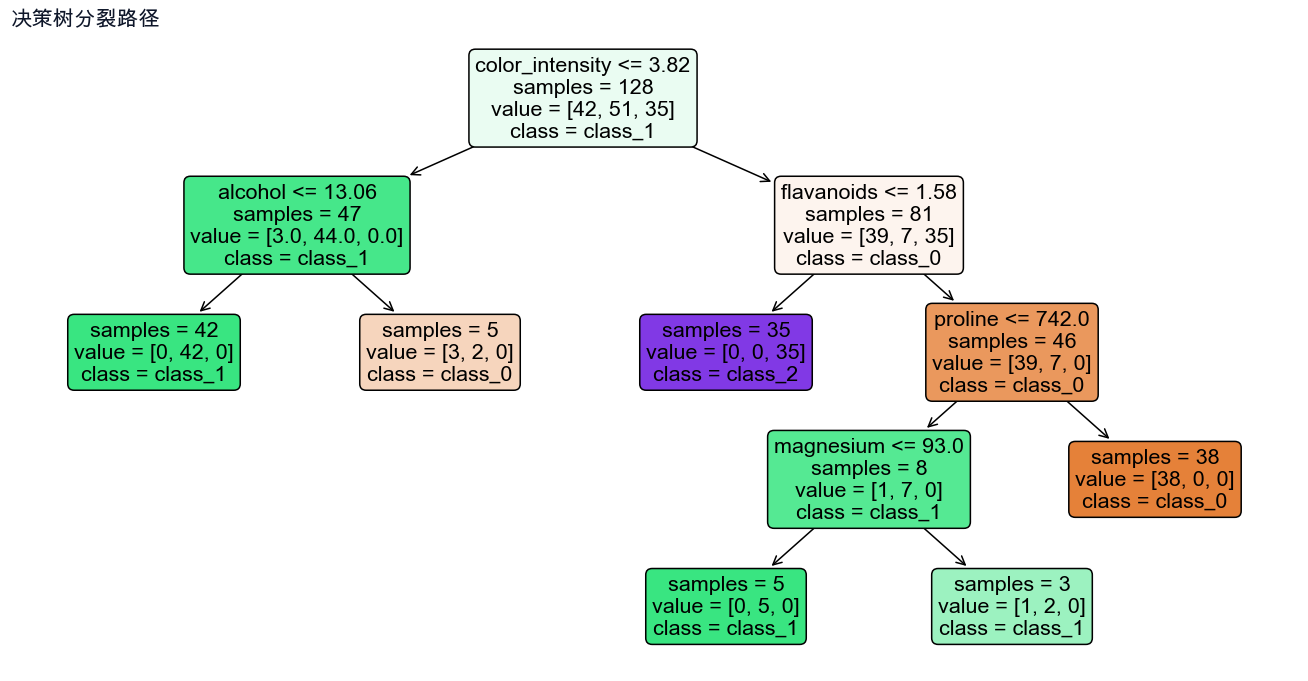

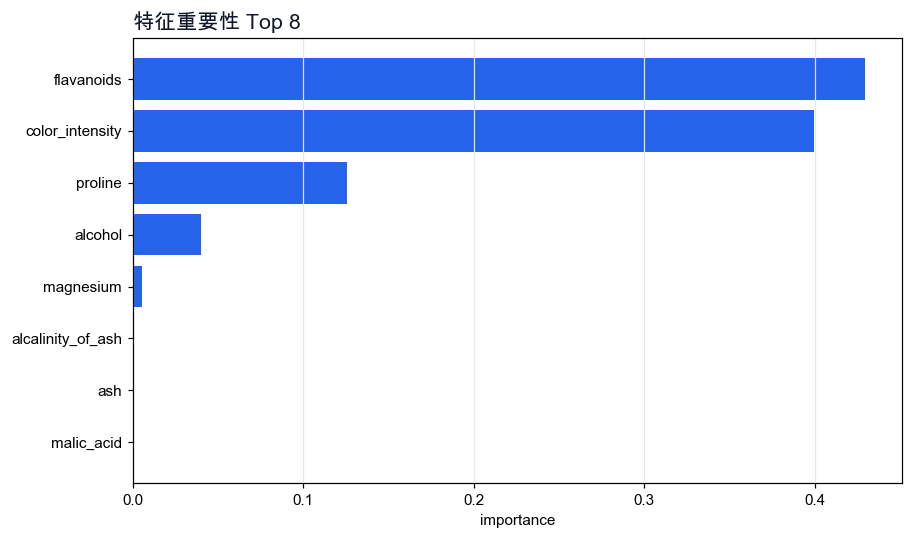

In [5]:
# 绘制树结构和特征重要性条形图。
fig, ax = plt.subplots(figsize=(12.0, 6.3))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
)
ax.set_title("决策树分裂路径", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()

top_importance = importance_df.head(8).sort_values("重要性")
fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.barh(top_importance["特征"], top_importance["重要性"], color="#2563eb")
ax.set_title("特征重要性 Top 8", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("importance")
ax.grid(True, axis="x", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

## 2. 鸢尾花聚类

聚类没有直接使用品种标签。这里用不同 k 比较簇的形状，再用真实品种做事后对照，理解聚类是否有意义。

In [6]:
# 加载 Iris 鸢尾花数据集，用四个形态特征做聚类。
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_feature_names = iris.feature_names
iris_class_names = list(iris.target_names)
iris_df["品种"] = iris_df["target"].map(dict(enumerate(iris_class_names)))

X_iris = iris_df[iris_feature_names]
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
pca = PCA(n_components=2, random_state=0)
iris_pca = pca.fit_transform(X_iris_scaled)

display(iris_df.head(8))
display(iris_df["品种"].value_counts().rename_axis("品种").reset_index(name="样本数"))
print("PCA 两个主成分解释方差:", np.round(pca.explained_variance_ratio_, 3))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,品种
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa


,品种,样本数
0,setosa,50
1,versicolor,50
2,virginica,50


PCA 两个主成分解释方差: [0.73  0.229]


In [7]:
# 比较不同 k：inertia 用于肘部曲线，silhouette 辅助判断聚类分离度。
k_values = range(1, 8)
kmeans_by_k = {}
labels_by_k = {}
metric_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=4)
    labels = model.fit_predict(X_iris_scaled)
    kmeans_by_k[k] = model
    labels_by_k[k] = labels
    metric_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": np.nan if k == 1 else silhouette_score(X_iris_scaled, labels),
        "ARI(对照真实品种)": np.nan if k == 1 else adjusted_rand_score(iris.target, labels),
    })

k_metrics = pd.DataFrame(metric_rows).round(3)
chosen_k = 3
kmeans = kmeans_by_k[chosen_k]
final_labels = labels_by_k[chosen_k]

clustered_iris = iris_df.copy()
clustered_iris["簇"] = final_labels
cluster_profile = clustered_iris.groupby("簇")[iris_feature_names].mean().round(2)
cluster_mix = pd.crosstab(clustered_iris["簇"], clustered_iris["品种"])

display(k_metrics)
display(cluster_profile)
display(cluster_mix)

,k,inertia,silhouette,ARI(对照真实品种)
0,1,600.000,NaN,NaN
1,2,222.362,0.582,0.568
2,3,139.820,0.460,0.620
3,4,114.097,0.387,0.462
4,5,91.047,0.341,0.436
5,6,79.999,0.323,0.350
6,7,70.764,0.325,0.300


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
簇,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


品种,setosa,versicolor,virginica
簇,,,
0,0,39,14
1,50,0,0
2,0,11,36


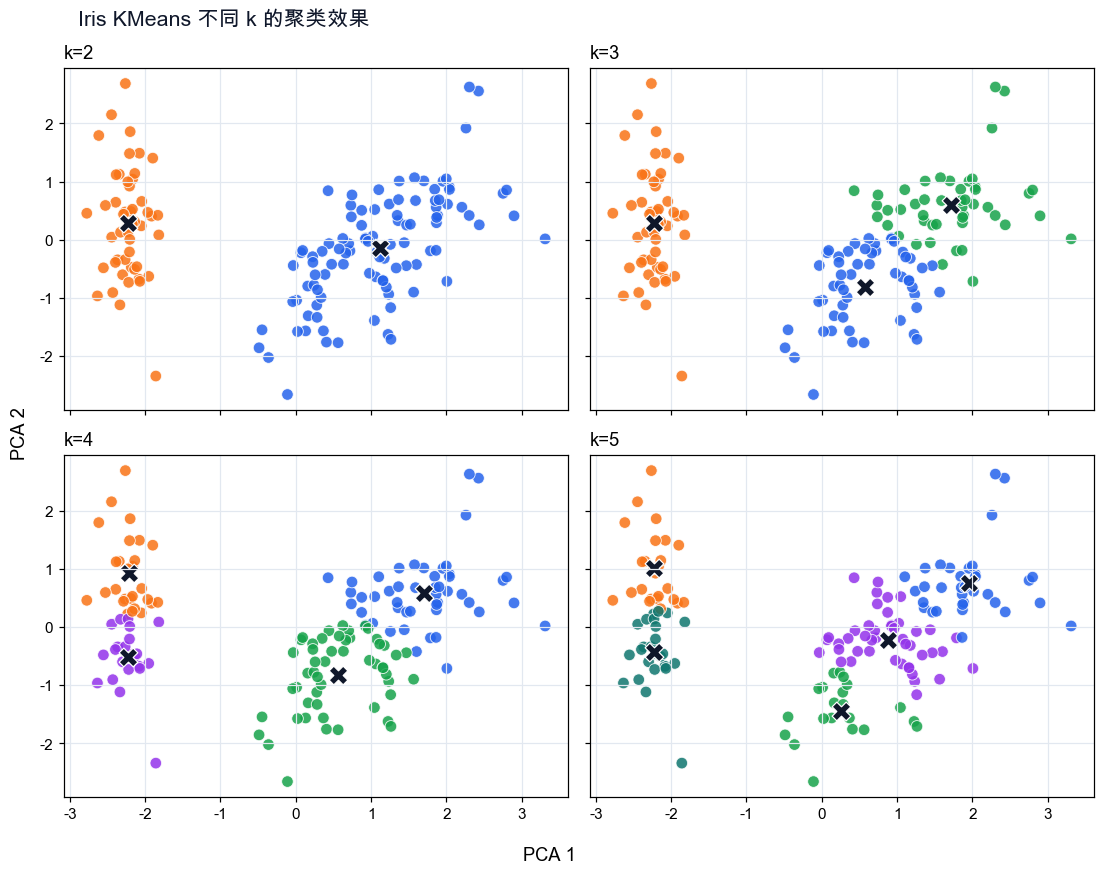

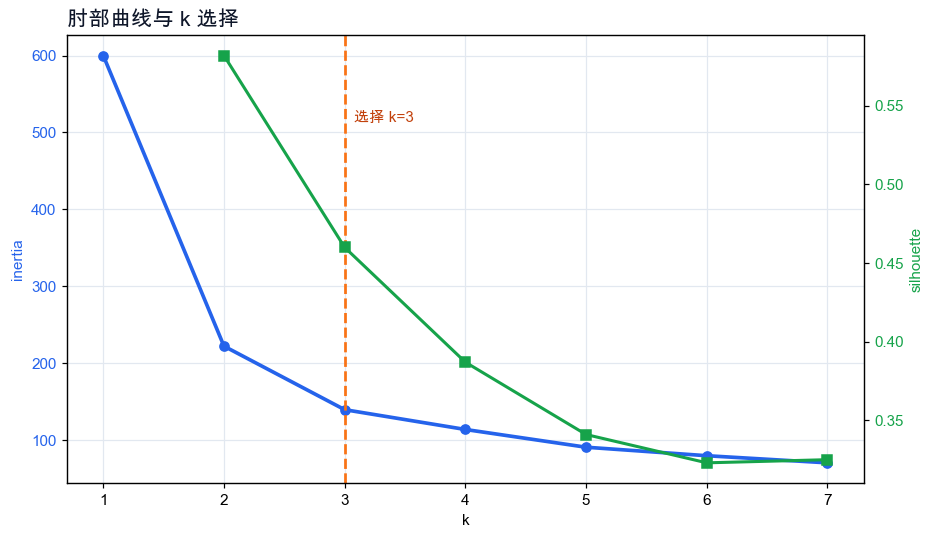

In [8]:
# 在 PCA 平面比较不同 k 的聚类结果。
palette = np.array(["#2563eb", "#f97316", "#16a34a", "#9333ea", "#0f766e", "#be123c", "#64748b"])
fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.0), sharex=True, sharey=True)
for ax, k in zip(axes.ravel(), [2, 3, 4, 5]):
    labels = labels_by_k[k]
    centers_2d = pca.transform(kmeans_by_k[k].cluster_centers_)
    ax.scatter(
        iris_pca[:, 0],
        iris_pca[:, 1],
        c=palette[labels],
        s=58,
        alpha=0.85,
        edgecolors="white",
        linewidth=0.6,
    )
    ax.scatter(
        centers_2d[:, 0],
        centers_2d[:, 1],
        marker="X",
        s=150,
        color="#0f172a",
        edgecolors="white",
        linewidth=0.8,
    )
    ax.set_title(f"k={k}", loc="left", fontweight="bold")
    ax.grid(True, color="#e2e8f0", linewidth=0.8)

fig.suptitle("Iris KMeans 不同 k 的聚类效果", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.supxlabel("PCA 1")
fig.supylabel("PCA 2")
plt.tight_layout()
plt.show()

# 肘部曲线观察 inertia 下降速度，k=3 后收益明显变小。
fig, ax1 = plt.subplots(figsize=(8.6, 5.0))
ax1.plot(k_metrics["k"], k_metrics["inertia"], marker="o", linewidth=2.4, color="#2563eb", label="inertia")
ax1.axvline(chosen_k, color="#f97316", linestyle="--", linewidth=1.8)
ax1.set_title("肘部曲线与 k 选择", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax1.set_xlabel("k")
ax1.set_ylabel("inertia", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")
ax1.grid(True, color="#e2e8f0", linewidth=0.8)

ax2 = ax1.twinx()
ax2.plot(k_metrics["k"], k_metrics["silhouette"], marker="s", linewidth=2.0, color="#16a34a", label="silhouette")
ax2.set_ylabel("silhouette", color="#16a34a")
ax2.tick_params(axis="y", labelcolor="#16a34a")
ax1.text(chosen_k + 0.08, ax1.get_ylim()[1] * 0.82, "选择 k=3", color="#c2410c", fontweight="bold")
plt.tight_layout()
plt.show()